# Explore here

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf


**Paso 1: Carga del conjunto de datos**

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre `sales.csv`. Puedes cargarlos en el código directamente desde el siguiente enlace:

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
total_data = pd.read_csv(url)
total_data

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


**Paso 2: Construye y analiza la serie temporal**

Construye la estructura de datos válida para la serie temporal, grafícala y, a continuación, analízala y responde a las siguientes preguntas:

1. ¿Cuál es el tensor de la serie temporal?
2. ¿Cuál es la tendencia?
3. ¿Es estacionaria?
4. ¿Existe variabilidad o presencia de ruido?

In [3]:
total_data["date"] = pd.to_datetime(total_data.date)
total_data = total_data.set_index("date")
ts= total_data["sales"]
ts.head()

date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

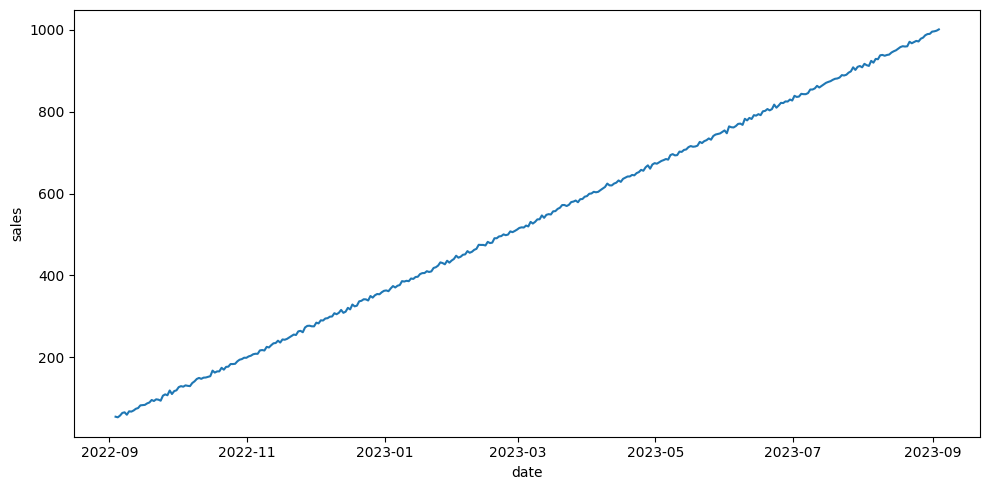

In [4]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)

plt.tight_layout()

plt.show()

##### Descomposición de la serie:
La descomposición de una serie temporal es un proceso estadístico que separa de una serie de tiempo en varios elementos diferenciados. Cada uno de estos componentes representa una parte de la estructura subyacente de la serie temporal. La descomposición de una serie de tiempo puede ser muy útil para entender mejor los datos y tomar decisiones informadas al construir modelos de pronóstico.

Utilizamos la función seasonal_decompose de la biblioteca statsmodels para descomponer la serie de tiempo en sus componentes de tendencia, estacionalidad y residuos.

In [5]:
decomposition = seasonal_decompose(ts, period = 12)
decomposition

##### Análisis de la tendencia:

La tendencia se refiere a la dirección general en la que se mueven los datos. Para acceder a su información recurrimos al componente trend del resultado decomposition.

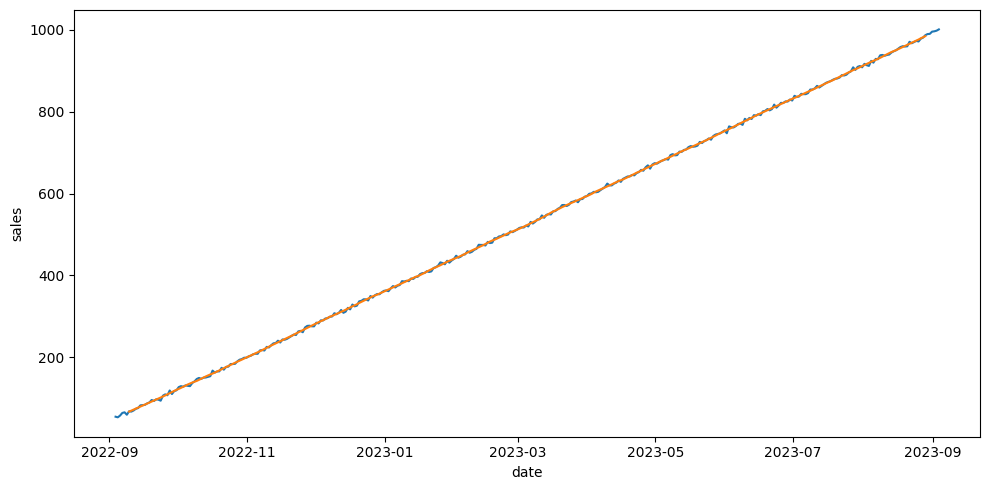

In [6]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

Se confirma lo observado: una clara tendencia positiva a lo largo de los años.

#### Análisis de la estacionalidad/estacionareidad:

La estacionalidad se refiere a los patrones repetitivos en los datos. Para acceder a su información recurrimos al componente seasonal del resultado decomposition.

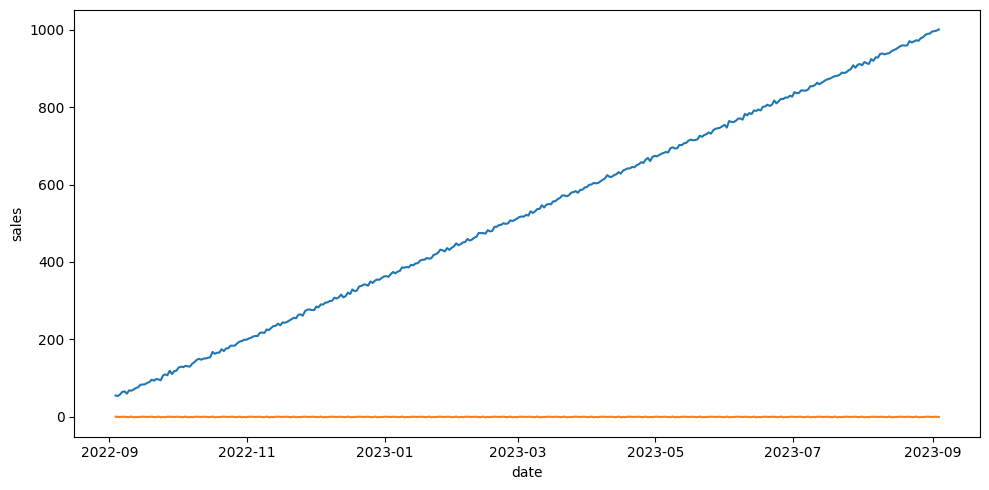

In [7]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Para evaluar la estacionalidad de la serie temporal podemos aplicar la llamada **Prueba de Dickey-Fuller (Dickey-Fuller test)**, que es un contraste de hipótesis en el que la hipótesis nula es que la serie es estacionaria, y la alternativa, que es no estacionaria:

In [8]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Aquí podemos ver que el p-value es mayor a 0.05, esto significa que nuestra hipótesis nula será rechazada y tomaremos esta serie como no estacionaria.

#### Análisis de la variabilidad:

La variabilidad implica el estudio de los residuos: que es cómo fluctúan los datos una vez se ha estudiado la tendencia y la estacionalidad. Para acceder a su información recurrimos al componente resid del resultado decomposition.

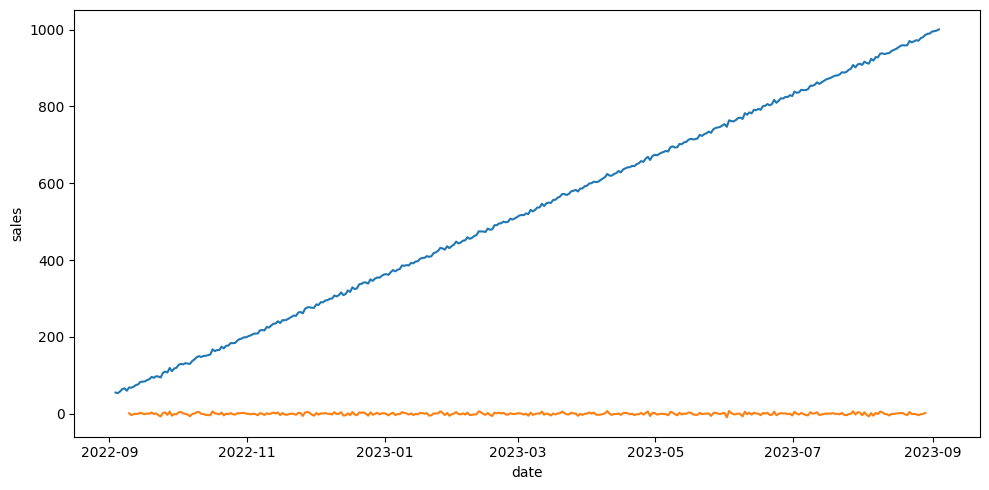

In [9]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

No se presencia mucha variabilidad en los datos. 

#### Análisis de la autocorrelación:

La autocorrelación es la correlación de una serie de tiempo con una copia retrasada de sí misma. Este gráfico nos ayuda a ver si los valores en la serie de tiempo están correlacionados con los valores anteriores.



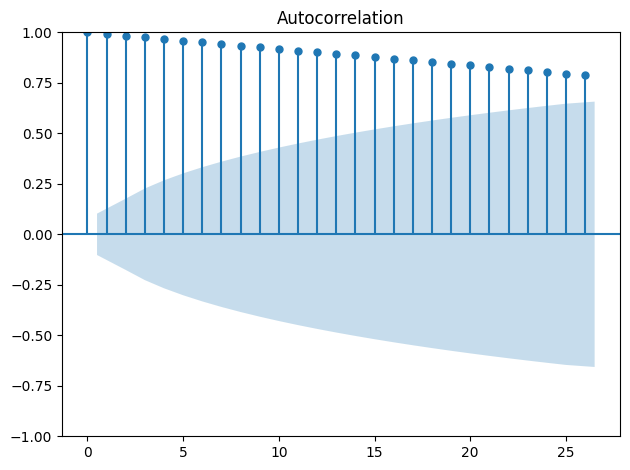

In [10]:
plot_acf(ts)

plt.tight_layout()

plt.show()

Perfecta correlación que disminuye en el tiempo, pero sigue siendo bastante alta

**Paso 3: Entrena un ARIMA**

Utiliza los datos de entrenamiento para encontrar la mejor parametrización de tu modelo ARIMA.

In [11]:
ts_stationary = ts.diff(12).diff().dropna()
test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -8.728367e+00
p-value                        3.241877e-14
#Lags Used                     1.700000e+01
Number of Observations Used    3.350000e+02
Critical Value (1%)           -3.450022e+00
Critical Value (5%)           -2.870207e+00
Critical Value (10%)          -2.571387e+00
dtype: float64

Es estacionaria ya que el p-value es menor que 0.05

In [12]:
model = auto_arima(ts_stationary, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2271.275, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2055.787, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2269.277, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=2161.222, Time=0.05 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=2017.902, Time=0.41 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2125.470, Time=0.55 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=1963.206, Time=0.66 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=2007.778, Time=0.21 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(3,0,0)(2,0,0)[12] intercept   : AIC=1947.1

In [13]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  353
Model:             SARIMAX(0, 0, 1)x(2, 0, [], 12)   Log Likelihood                -936.269
Date:                             Fri, 06 Mar 2026   AIC                           1880.538
Time:                                     13:49:11   BIC                           1896.004
Sample:                                 09-16-2022   HQIC                          1886.692
                                      - 09-03-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9512      0.018    -52.954      0.000      -0.986      -0.916
ar.S.L12      -0.6667      0.052    -12.739      0.000      -0.769      -0.564
ar.S.L24      -0.3537      0.054     -6.576      0.000      -0.459      -0.248
sigma2        11.4652      0.902     12.717      0.000       9.698      13.232
===================================================================================
Ljung-Box (L1) (Q):                   1.39   Jarque-Bera (JB):                 0.35
Prob(Q):                              0.24   Prob(JB):                         0.84
Heteroskedasticity (H):               0.98   Skew:                            -0.05
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Paso 4: Predice con el conjunto de test**

Ahora utiliza el modelo entrenado con el conjunto de prueba y compara los puntos con los reales. Mide el rendimiento de la serie temporal.

In [14]:
forecast = model.predict(60)

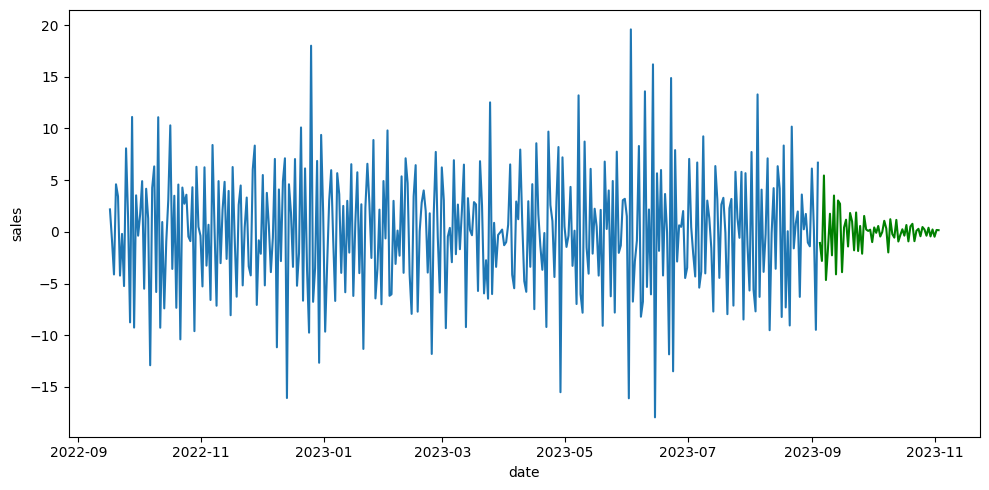

In [15]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts_stationary)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()